# 1.自由と幸福は比例するのか？

1254820222 神戸宗一郎

私が着目したのは、自由度と幸福度は比例しているのだろうかという点である。
自由な人は幸福度が高いのか、自由すぎることは息苦しいことではないのだろうか？
これらの疑問を解決していく

# 2.データの読み込み

In [4]:
# 必要なライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt

# CSVファイルを読み込む
df = pd.read_csv('world_happiness_report.csv')

# データの最初の5行を表示
df.head()

,Unnamed: 0,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
0,0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


In [5]:
# データの形状を確認（行数、列数）
print(f"データの形状: {df.shape}")

# データの基本情報
df.info()

データの形状: (1231, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     1231 non-null   int64  
 1   Country                        617 non-null    object 
 2   Region                         315 non-null    object 
 3   Happiness Rank                 315 non-null    float64
 4   Happiness Score                315 non-null    float64
 5   Standard Error                 158 non-null    float64
 6   Economy (GDP per Capita)       315 non-null    float64
 7   Family                         470 non-null    float64
 8   Health (Life Expectancy)       315 non-null    float64
 9   Freedom                        470 non-null    float64
 10  Trust (Government Corruption)  315 non-null    float64
 11  Generosity                     1084 non-null   float64
 12  Dystopia Residual            

In [6]:
# 基本統計量を表示
df.describe()

,Unnamed: 0,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
count,1231.000000,315.000000,315.000000,158.000000,315.000000,470.000000,315.000000,470.000000,315.000000,1084.000000,315.000000,1231.000000
mean,615.000000,79.238095,5.378949,0.047885,0.899837,0.990347,0.594054,0.402828,0.140532,0.153545,2.212032,2018.450041
std,355.503399,45.538922,1.141531,0.017146,0.410780,0.318707,0.240790,0.150356,0.115490,0.167592,0.558728,2.284034
min,0.000000,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,-0.300907,0.328580,2015.000000
25%,307.500000,40.000000,4.510000,0.037268,0.594900,0.793000,0.419645,0.297615,0.061315,0.064828,1.884135,2016.000000
50%,615.000000,79.000000,5.286000,0.043940,0.973060,1.025665,0.640450,0.418347,0.106130,0.162140,2.211260,2018.000000
75%,922.500000,118.500000,6.269000,0.052300,1.229000,1.228745,0.787640,0.516850,0.178610,0.252000,2.563470,2020.000000
max,1230.000000,158.000000,7.587000,0.136930,1.824270,1.610574,1.025250,0.669730,0.551910,0.838075,3.837720,2022.000000


# 3.分析

幸福度と自由度にどのような関係があるのか、分析していく

In [9]:
# 幸福度が高い順に並べ替え
# 列名の違いに対応（'Year' または 'year' のどちらかを使う）
year_col = 'Year' if 'Year' in df.columns else ('year' if 'year' in df.columns else None)

cols = ["Country", "Happiness Score", "Freedom"]
if year_col:
  cols.insert(1, year_col)

happiness_rank = (
  df.sort_values("Happiness Score", ascending=False)
    [cols]
    .head(20)
    .reset_index(drop=True)
)

# ランキング番号を1から付ける
happiness_rank.index += 1
happiness_rank.index.name = "Rank"

print("\n=== 幸福度ランキング TOP20 ===\n")
print(happiness_rank)


=== 幸福度ランキング TOP20 ===

          Country  year  Happiness Score  Freedom
Rank                                             
1     Switzerland  2015            7.587  0.66557
2         Iceland  2015            7.561  0.62877
3         Denmark  2015            7.527  0.64938
4         Denmark  2016            7.526  0.57941
5          Norway  2015            7.522  0.66973
6     Switzerland  2016            7.509  0.58557
7         Iceland  2016            7.501  0.56624
8          Norway  2016            7.498  0.59609
9          Canada  2015            7.427  0.63297
10        Finland  2016            7.413  0.57104
11        Finland  2015            7.406  0.64169
12         Canada  2016            7.404  0.57370
13    Netherlands  2015            7.378  0.61576
14         Sweden  2015            7.364  0.65980
15    Netherlands  2016            7.339  0.55211
16    New Zealand  2016            7.334  0.58147
17      Australia  2016            7.313  0.56837
18         Sweden  2016  

まず初めに分析したのは、Hapiness Scoreの高い国を上から20国表示した。
幸福度の高い国は、他の都市でも同じように幸福度が高く、1位はスイス、2位はアイスランド、3,4位はデンマークとなっており、いずれもヨーロッパの国々である。

In [11]:
# 自由度が高い順に並べ替え
# 列名 'Year' または 'year' のどちらかに対応
year_col = 'Year' if 'Year' in df.columns else ('year' if 'year' in df.columns else None)

cols_freedom = ["Country", "Freedom", "Happiness Score"]
if year_col:
    cols_freedom.insert(1, year_col)

freedom_rank = (
    df.sort_values("Freedom", ascending=False)
      [cols_freedom]
      .head(20)
      .reset_index(drop=True)
)

# ランキング番号を1から付ける
freedom_rank.index += 1
freedom_rank.index.name = "Rank"

print("\n=== 自由度ランキング TOP20 ===\n")
print(freedom_rank)


=== 自由度ランキング TOP20 ===

                   Country  year   Freedom  Happiness Score
Rank                                                       
1                   Norway  2015  0.669730            7.522
2              Switzerland  2015  0.665570            7.587
3                 Cambodia  2015  0.662460            3.819
4                   Sweden  2015  0.659800            7.364
5               Uzbekistan  2017  0.658249              NaN
6               Uzbekistan  2015  0.658210            6.003
7                Australia  2015  0.651240            7.284
8                  Denmark  2015  0.649380            7.527
9                  Finland  2015  0.641690            7.406
10    United Arab Emirates  2015  0.641570            6.901
11                   Qatar  2015  0.640400            6.611
12             New Zealand  2015  0.639380            7.286
13                  Norway  2017  0.635423              NaN
14              Costa Rica  2015  0.633760            7.226
15             

次に作成したのは、自由度のランキングである。Freedomの値が大きい順にランキングを作成した。
1位は幸福度ランキングで5位であったノルウェー。2位が幸福度ランキング1位のスイス。だが、注目するべきは3位はのカンボジアと5,6位のウズベキスタンである。これらの国は,幸福度ランキングトップ20圏外である。
幸福度と自由度にどれだけの関係があるのか、さらに分析してみる。

In [12]:
# 幸福度と自由度の相関
correlation = df["Happiness Score"].corr(df["Freedom"])

print("\n=== 幸福度と自由度の相関係数 ===")
print(correlation)


=== 幸福度と自由度の相関係数 ===
0.5564144422406025


幸福度と自由度の相関係数を調査したところ、約0.56、そこそこのやや関係ありという結果が出た。

# 4.可視化

ここからは相関係数と散布図で、幸福度と一番関係があるものは何なのか分析する。
下のグラフは、先ほどの幸福度と自由度の散布図である。

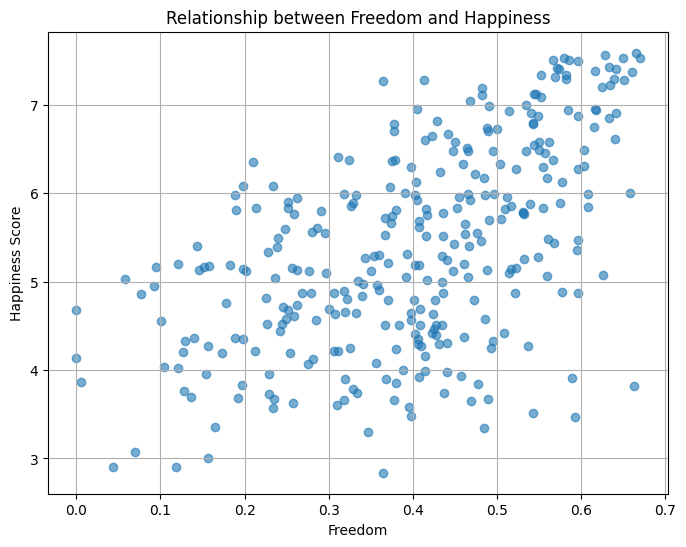

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Freedom"], df["Happiness Score"], alpha=0.6)
plt.xlabel("Freedom")
plt.ylabel("Happiness Score")
plt.title("Relationship between Freedom and Happiness")
plt.grid(True)
plt.show()

In [ ]:
# 幸福度と経済への貢献度の相関
correlation = df["Happiness Score"].corr(df["Economy (GDP per Capita)"])

print("\n=== 幸福度と経済への貢献度の相関係数 ===")
print(correlation)


=== 幸福度と経済への貢献度の相関係数 ===
0.7791710951128705


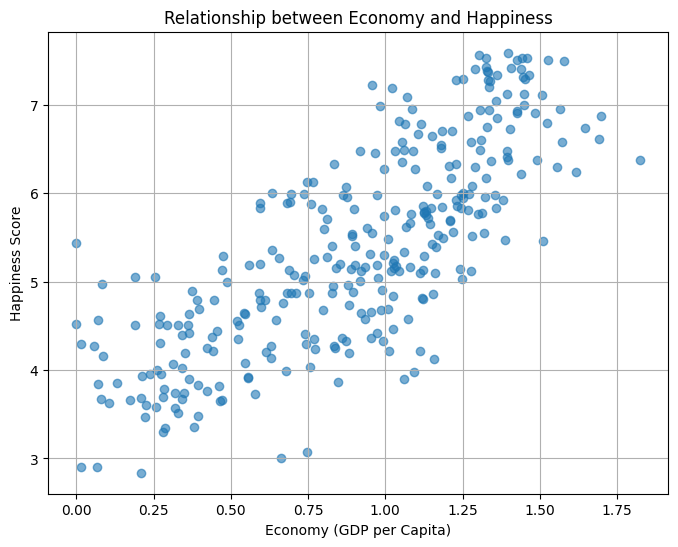

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Economy (GDP per Capita)"], df["Happiness Score"], alpha=0.6)
plt.xlabel("Economy (GDP per Capita)")
plt.ylabel("Happiness Score")
plt.title("Relationship between Economy and Happiness")
plt.grid(True)
plt.show()

続いて分析したのは、幸福度と経済への貢献度の相関係数と散布図である。
結果は相関係数約0.78と、強い相関があることが分かった。自由度よりも経済への貢献度の方が相関があるのであれば、
健康が幸福度とどのような相関があるのか気になったので分析していく。

In [16]:
# 幸福度と経済への貢献度の相関
correlation = df["Happiness Score"].corr(df["Health (Life Expectancy)"])

print("\n=== 幸福度と健康の相関係数 ===")
print(correlation)


=== 幸福度と健康の相関係数 ===
0.7344913751413351


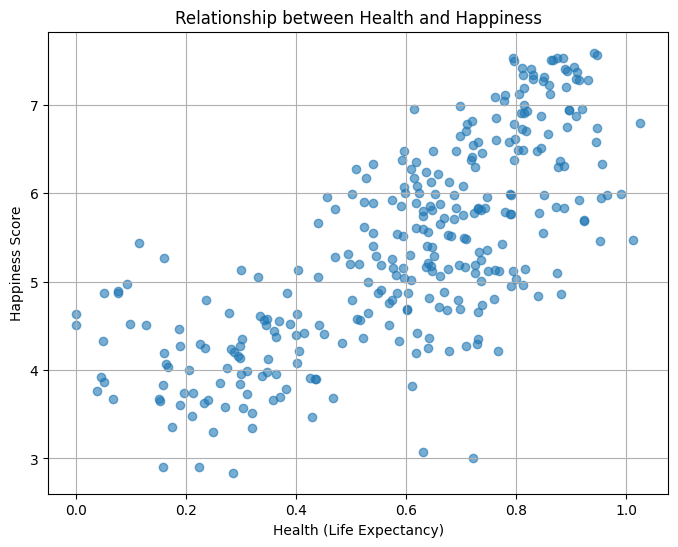

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Health (Life Expectancy)"], df["Happiness Score"], alpha=0.6)
plt.xlabel("Health (Life Expectancy)")
plt.ylabel("Happiness Score")
plt.title("Relationship between Health and Happiness")
plt.grid(True)
plt.show()

健康と幸福度の相関は、経済への貢献度ほどではないが、強い性の相関関係にある事が分かった。

# 5.結論

この3つの分析から、一番幸福度と比例しているのは経済への貢献度であるという事がわかった。
この経済への貢献度というのは、どれだけお金を使ったかの値であり、お金を持っている人ほど相対的に使えるお金も増えるため、
幸福はお金で買えるということが分かった。